In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
# from sklearn.decomposition import PCA
from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import r2_score



In [3]:
df = pd.read_csv(r"D:\Work_Station\Predicting_the_Beats_per_Minute_of_Songs\data\train.csv")
df = df.drop("id", axis =1)
df.head()

,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
0,0.603610,-7.636942,0.023500,0.000005,0.000001,0.051385,0.409866,290715.6450,0.826267,147.53020
1,0.639451,-16.267598,0.071520,0.444929,0.349414,0.170522,0.651010,164519.5174,0.145400,136.15963
2,0.514538,-15.953575,0.110715,0.173699,0.453814,0.029576,0.423865,174495.5667,0.624667,55.31989
3,0.734463,-1.357000,0.052965,0.001651,0.159717,0.086366,0.278745,225567.4651,0.487467,147.91212
4,0.532968,-13.056437,0.023500,0.068687,0.000001,0.331345,0.477769,213960.6789,0.947333,89.58511


In [4]:
df.describe()

,RhythmScore,AudioLoudness,VocalContent,AcousticQuality,InstrumentalScore,LivePerformanceLikelihood,MoodScore,TrackDurationMs,Energy,BeatsPerMinute
count,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000,524164.000000
mean,0.632843,-8.379014,0.074443,0.262913,0.117690,0.178398,0.555843,241903.692949,0.500923,119.034899
std,0.156899,4.616221,0.049939,0.223120,0.131845,0.118186,0.225480,59326.601501,0.289952,26.468077
min,0.076900,-27.509725,0.023500,0.000005,0.000001,0.024300,0.025600,63973.000000,0.000067,46.718000
25%,0.515850,-11.551933,0.023500,0.069413,0.000001,0.077637,0.403921,207099.876625,0.254933,101.070410
50%,0.634686,-8.252499,0.066425,0.242502,0.074247,0.166327,0.564817,243684.058150,0.511800,118.747660
75%,0.739179,-4.912298,0.107343,0.396957,0.204065,0.268946,0.716633,281851.658500,0.746000,136.686590
max,0.975000,-1.357000,0.256401,0.995000,0.869258,0.599924,0.978000,464723.228100,1.000000,206.037000


In [3]:
# for col in X.columns:
#     sns.scatterplot(x=df[col], y=df["BeatsPerMinute"])
#     plt.title(f"{col} vs BPM")
#     plt.show()

In [4]:
X = df.drop("BeatsPerMinute",axis =1)
y = df["BeatsPerMinute"]

In [5]:
y.nunique()

14622

## Train Val Test Split

In [6]:
scaler_X = MinMaxScaler()
X_scaled = scaler_X.fit_transform(X)

In [7]:
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size = 0.2, random_state= 42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

In [8]:
print(f"X_train: {round(len(X_train)/len(X)*100)}%")
print(f"X_val: {round(len(X_val)/len(X)*100)}%")
print(f"X_test: {round(len(X_test)/len(X)*100)}%")

X_train: 80%
X_val: 10%
X_test: 10%


## Min-Max Scaler
- ## To prevent Data Leakage
- Fit ONLY on training data
- Transform validation and test data


In [9]:
scaler_X = MinMaxScaler()

# For X
X_train_scaled = scaler_X.fit_transform(X_train)
X_val_scaled   = scaler_X.transform(X_val)
X_test_scaled  = scaler_X.transform(X_test)

# # For y
# # scaler_y = MinMaxScaler()
# # y_train_scaled = scaler_y.fit_transform(y_train.reshape(-1,1))
# # y_val_scaled   = scaler_y.transform(y_val.reshape(-1,1))
# # y_test_scaled  = scaler_y.transform(y_test.reshape(-1,1))

# # scaler_y = MinMaxScaler()
# # y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1, 1))
# # y_val_scaled   = scaler_y.transform(y_val.values.reshape(-1, 1))
# # y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1, 1))

In [10]:
# # Ready for ML models
# # -----------------------------
# print("\nSample of scaled features (X_train):\n", X_train_scaled[:5])
# print("\nSample of scaled target (y_train):\n", y_train_scaled[:5])

## PCA

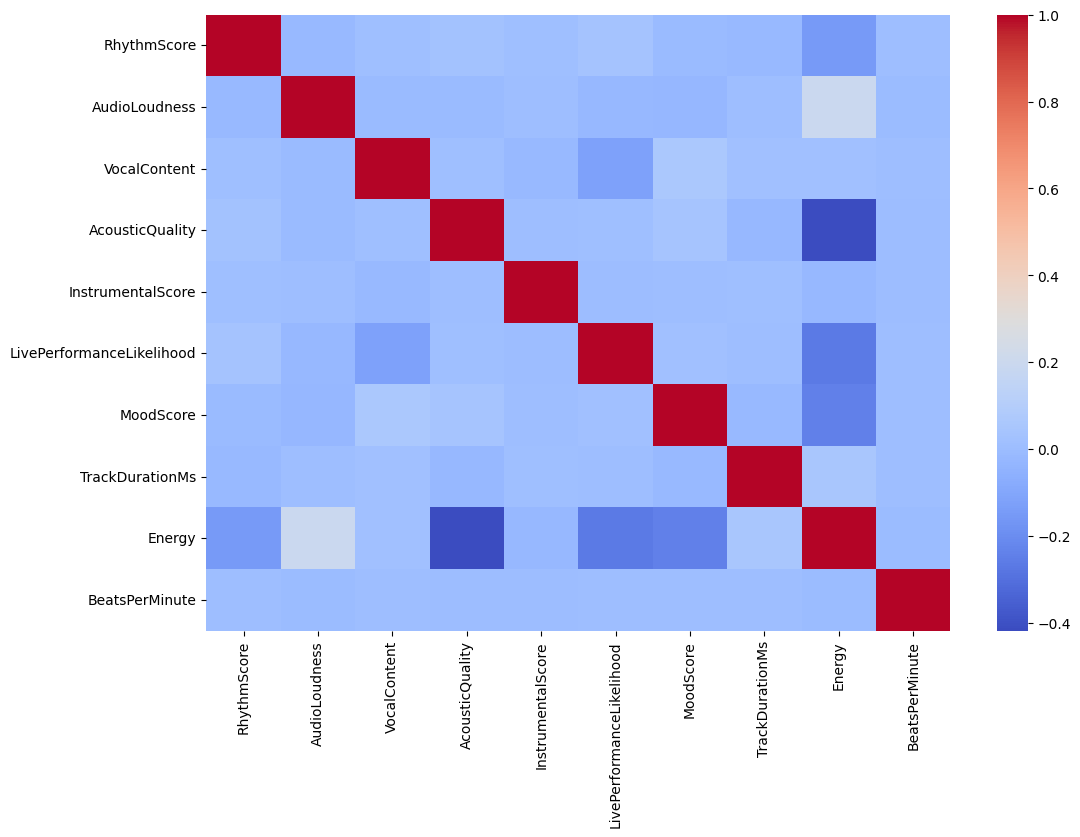

In [11]:
corr = df.corr()
plt.figure(figsize=(12,8))
sns.heatmap(corr, annot=False, cmap="coolwarm")
plt.show()

In [12]:
# pca  = PCA()
# X_train_pca = pca.fit_transform(X_train_scaled)
# X_val_pca = pca.transform(X_val_scaled)
# X_test_pca = pca.transform(X_test_scaled)

# plt.plot(np.cumsum(pca.explained_variance_ratio_))
# plt.xlabel("Number of Components")
# plt.ylabel("Cumulative Explained Variance")
# plt.title("PCA - Explained Variance")
# plt.show()

## Model Selection

- Training on Train and testing on Val

In [13]:
# from sklearn.linear_model import LinearRegression

# lr = LinearRegression()
# lr.fit(X_train_scaled, y_train)
# print("Val R²:", lr.score(X_val_scaled, y_val))
# print("Test R²:", lr.score(X_test_scaled, y_test))


In [14]:
model = XGBRegressor(
    random_state=42,
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8
)
model.fit(X_scaled, y)

# Validation evaluation
y_val_pred = model.predict(X_val_scaled)
rmse_val = np.sqrt(mean_squared_error(y_val, y_val_pred))
r2_val = r2_score(y_val, y_val_pred)

In [15]:
# Test evaluation
# -----------------------------
y_test_pred = model.predict(X_test_scaled)
rmse_test = np.sqrt(mean_squared_error(y_test, y_test_pred))
r2_test = r2_score(y_test, y_test_pred)

In [16]:
print("Validation Results:")
print(f"  RMSE: {rmse_val:.4f}")
print(f"  R²:   {r2_val:.4f}")


Validation Results:
  RMSE: 26.0764
  R²:   0.0264


In [17]:
print("\nTest Results:")
print(f"  RMSE: {rmse_test:.4f}")
print(f"  R²:   {r2_test:.4f}")


Test Results:
  RMSE: 26.1048
  R²:   0.0268


## Retrain on ALL data for Kaggle


In [18]:
X_scaled = scaler_X.fit_transform(X)  # refit scaler on all data
model.fit(X_scaled, y)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,0.8
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## Kaggle Submission

In [19]:
test_data = pd.read_csv(r"D:\Work_Station\Predicting_the_Beats_per_Minute_of_Songs\data\test.csv")
X_test_final = test_data.drop("id", axis=1)
X_test_scaled_final = scaler_X.transform(X_test_final)

In [20]:
y_test_pred_final = model.predict(X_test_scaled_final)


In [21]:
# X_test_scaled = scaler_X.transform(X_test_final)
# y_test_pred = model.predict(X_test_scaled)


In [22]:
# print("Validation R²:", r2_score(y_val, y_val_pred))
# print("Test R²:", r2_score(y_test, y_test_pred))

In [23]:
# # --- Evaluate on original scale ---
# print("Validation Results:")
# print(f"MSE:  {mean_squared_error(y_val, y_val_pred)}")
# print(f"RMSE: {np.sqrt(mean_squared_error(y_val, y_val_pred))}")
# print(f"R²:   {r2_score(y_val, y_val_pred)}")

# print("\nTest Results:")
# print(f"MSE:  {mean_squared_error(y_test, y_test_pred)}")
# print(f"RMSE: {np.sqrt(mean_squared_error(y_test, y_test_pred))}")
# print(f"R²:   {r2_score(y_test, y_test_pred)}")

In [24]:
# print(f"MSE: {mean_squared_error(y_val, y_val_pred)}")
# rmse = np.sqrt(mean_squared_error(y_val, y_val_pred))
# r2 = r2_score(y_val, y_val_pred)

# print(f"RMSE: {rmse}")
# print(f"R²: {r2}")

- Evaluate on Test Set

In [25]:
# y_test_pred = model.predict(X_test_scaled)
# print(f"MSE: {mean_squared_error(y_test, y_test_pred)}")
# rmse = np.sqrt(mean_squared_error(y_test, y_test_pred))
# r2 = r2_score(y_test, y_test_pred)

# print(f"RMSE: {rmse}")
# print(f"R²: {r2}")

In [26]:
# print(pca.explained_variance_ratio_)
# print(sum(pca.explained_variance_ratio_))


## Submit in Kaggle

In [27]:
sample_submission = pd.read_csv(r"D:\Work_Station\Predicting_the_Beats_per_Minute_of_Songs\data\sample_submission.csv")
sample_submission["BeatsPerMinute"] = y_test_pred_final



In [28]:
# Save final submission
sample_submission.to_csv("submission.csv", index=False)
print("✅ submission.csv file created successfully!")


✅ submission.csv file created successfully!
